In [2]:
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    widgets = None
from IPython.display import display


In [3]:
twopt_path = Path("hassan_2pt_left_crutch_right_damaged.csv")
threept_path = Path("hassan3pt_left_crutch_left_damaged.csv")
fourpt_path = Path("hassandata1_4pt_left_crutch_right_damaged.csv")
swing_path = Path("hassan_swing.csv")
data10_path = Path("data10_hassan.csv")
data11_path = Path("data11.csv")

DATASET_PATHS = {
    "swing": swing_path,
    "2pt": twopt_path,
    "3pt": threept_path,
    "4pt": fourpt_path,
    "data10": data10_path,
    "data11": data11_path,
    "instron": Path("instron_1_72mm.csv")
}
DATASET_DIR = Path("Rig_tests_and_analysis")

# Force/r_diff tuning.
MAG_SIGNAL_LABEL = "|mz_uT|"
MANUAL_BASELINE_RAW_MZ_UT = None
MAG_OFFSET_SUBTRACT_UT = -16
DB_TO_DR_MM_PER_UT = 0.009659183
FORCE_QUADRATIC_A = 182.467185
FORCE_QUADRATIC_B = 398.386356	
NEWTONS_PER_KG_FORCE = 9.80665
FORCE_PROFILE_END_COL = "confirm_s"

# Peak-relative release step detector tuning.
STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 50
Z_ENTER = 2.0
RELEASE_FRACTION = 0.1
RELEASE_CONFIRM_MS = 50.0
REFRACTORY_MS = 50.0
POST_RELEASE_BASELINE_SAMPLES = BASELINE_WINDOW_SAMPLES
SUSTAINED_CUTOFF_S = 5.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0
MIN_DURATION_S = 0.50
MIN_PEAK_FRAC_OF_MEDIAN = 0.30
MIN_AREA_FRAC_OF_MEDIAN = 0.30


def manual_baseline_signal_uT():
    if MANUAL_BASELINE_RAW_MZ_UT is None:
        return None
    return abs(MANUAL_BASELINE_RAW_MZ_UT) - MAG_OFFSET_SUBTRACT_UT


RAW_CAPTURE_COLS = [
    "seq", "timestamp_ms",
    "ax_g", "ay_g", "az_g",
    "gx_dps", "gy_dps", "gz_dps",
    "roll_deg", "pitch_deg", "yaw_deg",
    "mx_uT", "my_uT", "mz_uT",
]


def resolve_capture_path(path):
    path = Path(path)
    if path.exists():
        return path

    analysis_path = DATASET_DIR / path
    if analysis_path.exists():
        return analysis_path

    return path


def load_hassan_capture_csv(path):
    path = resolve_capture_path(path)
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if parts[0] == "seq":
                continue
            if len(parts) != len(RAW_CAPTURE_COLS):
                continue
            try:
                rows.append([float(p) for p in parts])
            except ValueError:
                continue

    if not rows:
        return pd.DataFrame(), path

    df = pd.DataFrame(rows, columns=RAW_CAPTURE_COLS)
    df["seq"] = df["seq"].astype(int)
    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
    df["accel_mag_g"] = np.sqrt(df["ax_g"]**2 + df["ay_g"]**2 + df["az_g"]**2)
    df["gyro_mag_dps"] = np.sqrt(df["gx_dps"]**2 + df["gy_dps"]**2 + df["gz_dps"]**2)
    return df, path


def add_force_columns(df):
    df = df.copy()
    field = df["mz_uT"].abs() - MAG_OFFSET_SUBTRACT_UT
    df["detector_signal_uT"] = field
    df["detector_signal_lpf_uT"] = field.ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()

    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    manual_b0 = manual_baseline_signal_uT()
    b0 = manual_b0 if manual_b0 is not None else startup["detector_signal_lpf_uT"].mean()
    return df, b0


def add_baseline_relative_force_columns(df):
    df = df.copy()
    df["db_uT"] = df["detector_signal_lpf_uT"] - df["baseline_mean"]
    df["mag_delta_uT"] = df["db_uT"]
    df["dr_mm"] = DB_TO_DR_MM_PER_UT * df["db_uT"]
    df["r_diff_mm"] = df["dr_mm"]
    force_displacement_mm = df["dr_mm"].clip(lower=0.0)
    df["force_direct_n"] = FORCE_QUADRATIC_A * force_displacement_mm**2 + FORCE_QUADRATIC_B * force_displacement_mm
    df["force_direct_kg"] = df["force_direct_n"] / NEWTONS_PER_KG_FORCE
    return df


def add_step_force_profile(df, events_df):
    df = df.copy()
    df["force_n"] = 0.0
    df["force_kg"] = 0.0

    events_df = events_df.copy()
    force_cols = {
        "force_profile_start_s": [],
        "force_profile_end_s": [],
        "peak_time_s": [],
        "peak_r_diff_mm": [],
        "peak_force_n": [],
        "peak_force_kg": [],
    }

    if events_df.empty:
        for col, values in force_cols.items():
            events_df[col] = values
        return df, events_df

    for event_idx, event in events_df.iterrows():
        start_s = event["start_s"]
        end_s = event.get(FORCE_PROFILE_END_COL, event["release_s"])
        event_mask = (df["time_s"] >= start_s) & (df["time_s"] <= end_s)
        event_df = df.loc[event_mask]

        if len(event_df) < 2:
            force_cols["force_profile_start_s"].append(start_s)
            force_cols["force_profile_end_s"].append(end_s)
            force_cols["peak_time_s"].append(np.nan)
            force_cols["peak_r_diff_mm"].append(0.0)
            force_cols["peak_force_n"].append(0.0)
            force_cols["peak_force_kg"].append(0.0)
            continue

        peak_idx = event_df["r_diff_mm"].idxmax()
        peak_r_diff = float(df.loc[peak_idx, "r_diff_mm"])
        peak_force = float(df.loc[event_mask, "force_direct_n"].max())
        peak_force_kg = peak_force / NEWTONS_PER_KG_FORCE

        t = event_df["time_s"].to_numpy(dtype="float64")
        r_diff = event_df["r_diff_mm"].to_numpy(dtype="float64")
        edge_line = np.interp(t, [t[0], t[-1]], [r_diff[0], r_diff[-1]])
        force_shape = np.clip(r_diff - edge_line, 0.0, None)
        shape_peak = force_shape.max()

        if event.get("accepted", True) and peak_force > 0 and shape_peak > 0:
            profile = peak_force * force_shape / shape_peak
            df.loc[event_mask, "force_n"] = np.maximum(df.loc[event_mask, "force_n"], profile)
            df.loc[event_mask, "force_kg"] = np.maximum(df.loc[event_mask, "force_kg"], profile / NEWTONS_PER_KG_FORCE)

        force_cols["force_profile_start_s"].append(start_s)
        force_cols["force_profile_end_s"].append(end_s)
        force_cols["peak_time_s"].append(float(df.loc[peak_idx, "time_s"]))
        force_cols["peak_r_diff_mm"].append(peak_r_diff)
        force_cols["peak_force_n"].append(peak_force)
        force_cols["peak_force_kg"].append(peak_force_kg)

    for col, values in force_cols.items():
        events_df[col] = values
    return df, events_df


def event_area(df, start_s, release_s, baseline):
    event_df = df[(df["time_s"] >= start_s) & (df["time_s"] <= release_s)]
    if len(event_df) < 2:
        return 0.0
    y = (event_df["detector_signal_lpf_uT"] - baseline).clip(lower=0.0)
    return float(np.trapz(y, event_df["time_s"]))


def classify_rejections(events_df):
    if events_df.empty:
        events_df["accepted"] = []
        events_df["reject_reason"] = []
        return events_df

    median_peak_amp = events_df["peak_amp"].median()
    median_area = events_df["area"].median()

    accepted = []
    reasons = []
    for row in events_df.itertuples(index=False):
        reason_parts = []
        if row.duration_s < MIN_DURATION_S:
            reason_parts.append("short")
        if median_peak_amp > 0 and row.peak_amp < MIN_PEAK_FRAC_OF_MEDIAN * median_peak_amp:
            reason_parts.append("small_peak")
        if median_area > 0 and row.area < MIN_AREA_FRAC_OF_MEDIAN * median_area:
            reason_parts.append("small_area")
        accepted.append(not reason_parts)
        reasons.append(",".join(reason_parts))

    events_df = events_df.copy()
    events_df["accepted"] = accepted
    events_df["reject_reason"] = reasons
    events_df["median_peak_amp"] = median_peak_amp
    events_df["median_area"] = median_area
    return events_df


def run_peak_release_pipeline(df):
    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    manual_b0 = manual_baseline_signal_uT()
    if manual_b0 is not None:
        startup_std_floor = STD_FLOOR
        baseline_window = deque([manual_b0] * BASELINE_WINDOW_SAMPLES, maxlen=BASELINE_WINDOW_SAMPLES)
    else:
        startup_std_floor = max(startup["detector_signal_lpf_uT"].std(ddof=1), STD_FLOOR)
        baseline_window = deque(startup["detector_signal_lpf_uT"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)

    def window_stats(window):
        vals = pd.Series(list(window), dtype="float64")
        mean = vals.mean()
        std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
        return mean, max(std, startup_std_floor)

    def update_rolling_baseline(window, b):
        window.append(b)
        return window_stats(window)

    baseline_mean, baseline_std = window_stats(baseline_window)
    state = "idle"
    load_start_t = None
    release_candidate_t = None
    last_release_t = -1e9
    post_release_baseline_samples = 0
    baseline_at_entry = None
    peak_signal = None
    release_level = np.nan
    events = []

    states = []
    baseline_means = []
    baseline_stds = []
    z_scores = []
    release_levels = []
    peak_values = []

    for row in df.itertuples(index=False):
        t = row.time_s
        b = row.detector_signal_lpf_uT

        if t <= STARTUP_ZERO_S:
            if manual_b0 is None:
                baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
            states.append("zeroing")
            baseline_means.append(baseline_mean)
            baseline_stds.append(baseline_std)
            z_scores.append(0.0)
            release_levels.append(np.nan)
            peak_values.append(np.nan)
            continue

        z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

        if state == "idle":
            can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
            if can_start and z >= Z_ENTER:
                state = "loaded"
                load_start_t = t
                release_candidate_t = None
                baseline_at_entry = baseline_mean
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)
                post_release_baseline_samples = 0
            elif post_release_baseline_samples > 0:
                if manual_b0 is None:
                    baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
                post_release_baseline_samples -= 1
            release_levels.append(np.nan)
            peak_values.append(np.nan)

        elif state == "loaded":
            if b > peak_signal:
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)

            if b <= release_level:
                state = "releasing"
                release_candidate_t = t

            release_levels.append(release_level)
            peak_values.append(peak_signal)

        elif state == "releasing":
            if b > peak_signal:
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)

            if b > release_level:
                state = "loaded"
                release_candidate_t = None
            elif (t - release_candidate_t) * 1000.0 >= RELEASE_CONFIRM_MS:
                release_t = release_candidate_t
                duration_s = release_t - load_start_t
                kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
                peak_amp = peak_signal - baseline_at_entry
                area = event_area(df, load_start_t, release_t, baseline_at_entry)
                events.append({
                    "start_s": load_start_t,
                    "release_s": release_t,
                    "confirm_s": t,
                    "duration_s": duration_s,
                    "kind": kind,
                    "baseline_at_entry": baseline_at_entry,
                    "peak_signal_uT": peak_signal,
                    "peak_amp": peak_amp,
                    "area": area,
                    "release_level": release_level,
                })

                # Start the next unloaded baseline at the detected release point,
                # not at the later confirmation point.
                release_samples = df.loc[
                    (df["time_s"] >= release_t) & (df["time_s"] <= t),
                    "detector_signal_lpf_uT",
                ]
                if manual_b0 is None:
                    baseline_window.clear()
                    for sample in release_samples:
                        baseline_window.append(sample)
                    baseline_mean, baseline_std = window_stats(baseline_window)
                    post_release_baseline_samples = max(
                        POST_RELEASE_BASELINE_SAMPLES - len(release_samples),
                        0,
                    )
                else:
                    baseline_mean = manual_b0
                    baseline_std = STD_FLOOR
                    post_release_baseline_samples = 0

                state = "idle"
                load_start_t = None
                release_candidate_t = None
                last_release_t = t
                baseline_at_entry = None
                peak_signal = None
                release_level = np.nan

            release_levels.append(release_level)
            peak_values.append(peak_signal if peak_signal is not None else np.nan)

        states.append(state)
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)

    out = df.copy()
    out["state"] = states
    out["baseline_mean"] = baseline_means
    out["baseline_std"] = baseline_stds
    out["z_score"] = z_scores
    out["release_level"] = release_levels
    out["peak_signal_uT"] = peak_values
    events_df = classify_rejections(pd.DataFrame(events))
    return out, events_df


def analyze_dataset(dataset_name):
    csv_path = DATASET_PATHS[dataset_name]
    raw_df, csv_path = load_hassan_capture_csv(csv_path)
    if raw_df.empty:
        print(f"No raw 14-column Hassan capture rows in {csv_path}")
        return None, pd.DataFrame(), csv_path, np.nan

    force_df, startup_b0 = add_force_columns(raw_df)
    detected_df, events_df = run_peak_release_pipeline(force_df)
    detected_df = add_baseline_relative_force_columns(detected_df)
    detected_df, events_df = add_step_force_profile(detected_df, events_df)
    if len(events_df):
        events_df = events_df.copy()
        events_df.insert(0, "dataset", dataset_name)
        events_df.insert(1, "file", str(csv_path))
    return detected_df, events_df, csv_path, startup_b0


def plot_peak_release_dataset(dataset_name):
    detected_df, events_df, csv_path, startup_b0 = analyze_dataset(dataset_name)
    if detected_df is None:
        return

    accepted_df = events_df[events_df["accepted"]] if len(events_df) else events_df
    rejected_df = events_df[~events_df["accepted"]] if len(events_df) else events_df
    steps = int((accepted_df["kind"] == "step").sum()) if len(accepted_df) else 0
    sustained = int((accepted_df["kind"] == "sustained").sum()) if len(accepted_df) else 0

    display(pd.Series({
        "dataset": dataset_name,
        "file": str(csv_path),
        "rows": len(detected_df),
        "duration_s": detected_df["time_s"].iloc[-1],
        "mag_signal_for_detector": MAG_SIGNAL_LABEL,
        "manual_baseline_raw_mz_uT": MANUAL_BASELINE_RAW_MZ_UT,
        "mag_offset_subtract_uT": MAG_OFFSET_SUBTRACT_UT,
        "db_to_dr_mm_per_uT": DB_TO_DR_MM_PER_UT,
        "force_model": f"force_kg = ({FORCE_QUADRATIC_A:.6f} * dr_mm^2 + {FORCE_QUADRATIC_B:.6f} * dr_mm) / {NEWTONS_PER_KG_FORCE:.5f}",
        "force_quadratic_a": FORCE_QUADRATIC_A,
        "force_quadratic_b": FORCE_QUADRATIC_B,
        "newtons_per_kg_force": NEWTONS_PER_KG_FORCE,
        "startup_b0_uT": startup_b0,
        "candidates": len(events_df),
        "accepted": len(accepted_df),
        "rejected": len(rejected_df),
        "steps": steps,
        "sustained": sustained,
        "max_z": detected_df["z_score"].max(),
        "max_mag_delta_uT": detected_df["mag_delta_uT"].max(),
        "max_r_diff_mm": detected_df["r_diff_mm"].max(),
        "max_force_direct_kg": detected_df["force_direct_kg"].max(),
    }, name="peak-release summary"))

    cols = ["dataset", "start_s", "release_s", "confirm_s", "duration_s", "kind", "accepted", "reject_reason", "peak_amp", "peak_r_diff_mm", "peak_force_kg", "area"]
    display(events_df[cols] if len(events_df) else events_df)

    fig, axs = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

    axs[0].plot(detected_df["time_s"], detected_df["db_uT"], lw=0.9, label="db = smoothed |mz_uT| - baseline")
    axs[0].axhline(0, color="0.35", lw=0.7, alpha=0.5)
    axs[0].set_ylabel("db (uT)")
    axs[0].legend(loc="upper right")
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(detected_df["time_s"], detected_df["dr_mm"], lw=0.9, color="C2", label=f'dr = {DB_TO_DR_MM_PER_UT:.6f} * db')
    axs[1].axhline(0, color="0.35", lw=0.7, alpha=0.5)
    axs[1].set_ylabel("dr (mm)")
    axs[1].legend(loc="upper right")
    axs[1].grid(True, alpha=0.3)

    axs[2].plot(
        detected_df["time_s"],
        detected_df["force_direct_kg"],
        lw=0.9,
        color="C3",
        label=f'force = ({FORCE_QUADRATIC_A:.6f} * dr^2 + {FORCE_QUADRATIC_B:.6f} * dr) / {NEWTONS_PER_KG_FORCE:.5f}',
    )
    axs[2].axhline(0, color="0.35", lw=0.7, alpha=0.5)
    axs[2].set_ylabel("force (kg)")
    axs[2].legend(loc="upper right")
    axs[2].grid(True, alpha=0.3)

    axs[3].plot(detected_df["time_s"], detected_df["roll_deg"], lw=0.85, color="C6", label="roll_deg")
    axs[3].axhline(0, color="0.35", lw=0.7, alpha=0.5)
    axs[3].set_ylabel("roll (deg)")
    axs[3].set_xlabel("time (s)")
    axs[3].legend(loc="upper right")
    axs[3].grid(True, alpha=0.3)

    for event in events_df.to_dict("records"):
        if not event["accepted"]:
            color = "0.5"
        elif event["kind"] == "step":
            color = "C2"
        else:
            color = "C1"
        alpha = 0.10 if not event["accepted"] else 0.16
        for ax in axs:
            ax.axvspan(event["start_s"], event["confirm_s"], color=color, alpha=alpha)

    fig.suptitle(
        f"{dataset_name} peak-relative release: accepted={len(accepted_df)}, rejected={len(rejected_df)}, "
        f"steps={steps}, sustained={sustained}"
    )
    plt.tight_layout()
    plt.show()


def compare_peak_release_datasets():
    rows = []
    all_events = []
    for dataset_name in DATASET_PATHS:
        detected_df, events_df, csv_path, _ = analyze_dataset(dataset_name)
        if detected_df is None:
            continue
        accepted_df = events_df[events_df["accepted"]] if len(events_df) else events_df
        rejected_df = events_df[~events_df["accepted"]] if len(events_df) else events_df
        rows.append({
            "dataset": dataset_name,
            "file": str(csv_path),
            "candidates": len(events_df),
            "accepted": len(accepted_df),
            "rejected": len(rejected_df),
            "steps": int((accepted_df["kind"] == "step").sum()) if len(accepted_df) else 0,
            "sustained": int((accepted_df["kind"] == "sustained").sum()) if len(accepted_df) else 0,
            "max_z": round(float(detected_df["z_score"].max()), 1),
            "max_r_diff_mm": round(float(detected_df["r_diff_mm"].max()), 3),
            "max_force_direct_kg": round(float(detected_df["force_direct_kg"].max()), 3),
        })
        all_events.append(events_df)

    summary_df = pd.DataFrame(rows)
    events_table = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()
    display(summary_df)
    cols = ["dataset", "start_s", "release_s", "confirm_s", "duration_s", "kind", "accepted", "reject_reason", "peak_amp", "peak_r_diff_mm", "peak_force_kg", "area"]
    display(events_table[cols] if len(events_table) else events_table)


def plot_magnetometer_force_dataset(dataset_name):
    detected_df, events_df, csv_path, startup_b0 = analyze_dataset(dataset_name)
    if detected_df is None:
        return

    display(pd.Series({
        "dataset": dataset_name,
        "file": str(csv_path),
        "rows": len(detected_df),
        "duration_s": detected_df["time_s"].iloc[-1],
        "startup_baseline_uT": startup_b0,
        "db_to_dr_mm_per_uT": DB_TO_DR_MM_PER_UT,
        "force_model": f"force_kg = ({FORCE_QUADRATIC_A:.6f} * dr_mm^2 + {FORCE_QUADRATIC_B:.6f} * dr_mm) / {NEWTONS_PER_KG_FORCE:.5f}",
        "max_mag_delta_uT": detected_df["mag_delta_uT"].max(),
        "max_r_diff_mm": detected_df["r_diff_mm"].max(),
        "max_force_direct_kg": detected_df["force_direct_kg"].max(),
    }, name="magnetometer-force summary"))

    fig, axs = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

    axs[0].plot(detected_df["time_s"], detected_df["mz_uT"], lw=0.75, color="C0", label="raw mz_uT")
    axs[0].plot(detected_df["time_s"], detected_df["mag_delta_uT"], lw=1.0, color="C1", label="smoothed |mz_uT| - baseline")
    axs[0].axhline(0, color="0.35", lw=0.7, alpha=0.5)
    axs[0].set_ylabel("magnetometer (uT)")
    axs[0].legend(loc="upper right")
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(detected_df["time_s"], detected_df["force_direct_kg"], lw=1.0, color="C3", label="estimated force")
    axs[1].axhline(0, color="0.35", lw=0.7, alpha=0.5)
    axs[1].set_ylabel("force (kg)")
    axs[1].set_xlabel("time (s)")
    axs[1].legend(loc="upper right")
    axs[1].grid(True, alpha=0.3)

    fig.suptitle(f"{dataset_name}: magnetometer reading converted to kg")
    plt.tight_layout()
    plt.show()


,dataset,file,candidates,accepted,rejected,steps,sustained,max_z,max_r_diff_mm,max_force_direct_kg
0,swing,hassan_swing.csv,13,13,0,13,0,22.5,1.044,62.657
1,2pt,hassan_2pt_left_crutch_right_damaged.csv,10,10,0,10,0,58.1,0.895,51.291
2,3pt,hassan3pt_left_crutch_left_damaged.csv,16,15,1,15,0,11.6,0.913,52.606
3,4pt,hassandata1_4pt_left_crutch_right_damaged.csv,13,9,4,9,0,70.6,0.699,37.503
4,data10,data10_hassan.csv,7,7,0,7,0,19.9,0.382,18.226
5,data11,data11.csv,5,3,2,0,3,34.3,0.331,15.482
6,instron,instron_1_72mm.csv,10,10,0,9,1,154.9,1.496,102.419


,dataset,start_s,release_s,confirm_s,duration_s,kind,accepted,reject_reason,peak_amp,peak_r_diff_mm,peak_force_kg,area
0,swing,1.683,3.234,3.300,1.551,step,True,,77.849923,0.751967,41.069073,52.721076
1,swing,3.861,4.719,4.785,0.858,step,True,,71.825967,0.693780,37.140068,34.615973
2,swing,6.138,6.798,6.864,0.660,step,True,,68.303506,0.659756,34.900989,29.237019
3,swing,8.184,8.976,9.042,0.792,step,True,,80.680807,0.779311,42.958977,35.769629
4,swing,10.560,11.187,11.253,0.627,step,True,,68.867103,0.665200,35.256348,26.297243
...,...,...,...,...,...,...,...,...,...,...,...,...
69,instron,37.356,39.270,39.336,1.914,step,True,,137.637143,1.329462,86.894603,140.090306
70,instron,40.590,42.471,42.537,1.881,step,True,,137.607133,1.329172,86.868488,139.410960
71,instron,43.791,45.705,45.771,1.914,step,True,,137.958450,1.332566,87.174406,143.038446
72,instron,47.058,48.906,48.972,1.848,step,True,,136.756072,1.320952,86.129184,138.135910


dataset                                                                    3pt
file                                    hassan3pt_left_crutch_left_damaged.csv
rows                                                                      1408
duration_s                                                              46.431
mag_signal_for_detector                                                |mz_uT|
manual_baseline_raw_mz_uT                                                 None
mag_offset_subtract_uT                                                     -16
db_to_dr_mm_per_uT                                                    0.009659
force_model                  force_kg = (182.467185 * dr_mm^2 + 398.386356 ...
force_quadratic_a                                                   182.467185
force_quadratic_b                                                   398.386356
newtons_per_kg_force                                                   9.80665
startup_b0_uT                                       

,dataset,start_s,release_s,confirm_s,duration_s,kind,accepted,reject_reason,peak_amp,peak_r_diff_mm,peak_force_kg,area
0,3pt,1.023,1.848,1.914,0.825,step,True,,34.891882,0.337027,15.804881,20.716845
1,3pt,3.300,4.488,4.554,1.188,step,True,,73.049693,0.705600,37.928021,55.899387
2,3pt,6.435,7.755,7.821,1.320,step,True,,84.165916,0.812974,45.323855,76.229597
3,3pt,9.735,10.692,10.758,0.957,step,True,,74.856642,0.723054,39.101017,46.425476
4,3pt,12.870,14.058,14.124,1.188,step,True,,85.578158,0.826615,46.294161,63.220663
5,3pt,16.071,17.061,17.127,0.990,step,True,,84.343318,0.814688,45.445362,56.419013
6,3pt,19.833,21.351,21.417,1.518,step,True,,28.052567,0.270965,12.373829,29.430356
7,3pt,22.275,23.298,23.364,1.023,step,True,,46.274327,0.446972,21.875123,30.583483
8,3pt,24.651,25.608,25.674,0.957,step,True,,70.367471,0.679692,36.207738,40.247581
9,3pt,26.433,28.380,28.446,1.947,step,True,,94.531014,0.913092,52.606476,144.997693


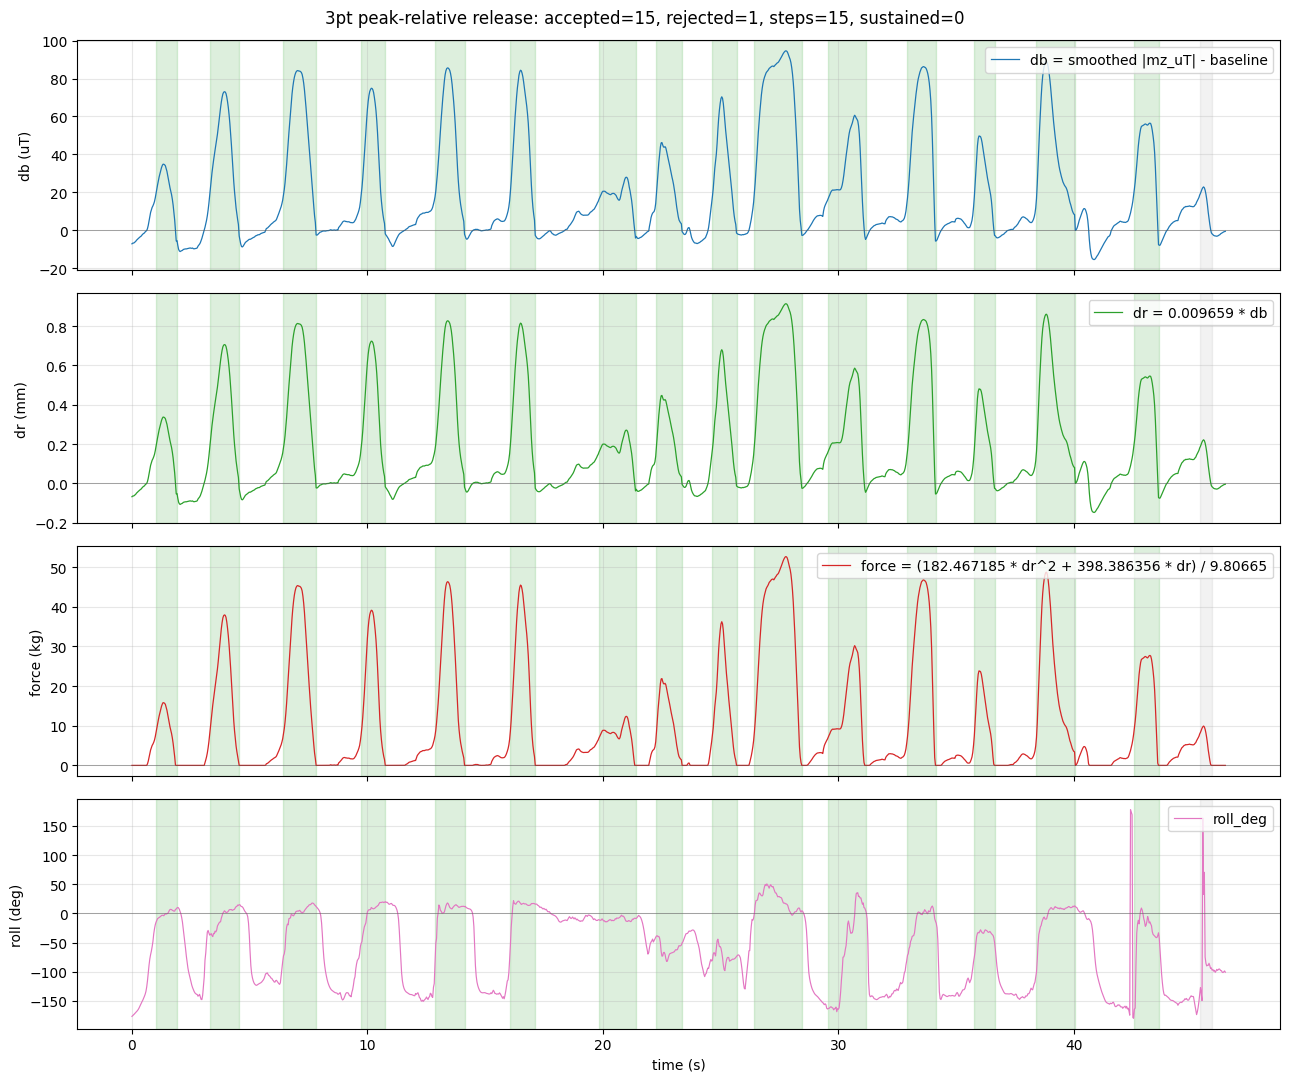

In [8]:
# RUN THIS CELL TO PLOT DATA10 MAGNETOMETER AND FORCE IN KG
# plot_magnetometer_force_dataset("swing")

# Optional comparisons:
compare_peak_release_datasets()
plot_peak_release_dataset("3pt") # try either "data10", "data11", "swing", "2pt", "3pt", or "4pt"

dataset                                                           data11
file                                                          data11.csv
rows                                                                3022
duration_s                                                       105.836
startup_baseline_uT                                           769.163015
db_to_dr_mm_per_uT                                              0.009659
force_model            force_kg = (182.467185 * dr_mm^2 + 398.386356 ...
max_mag_delta_uT                                               34.261375
max_r_diff_mm                                                   0.330937
max_force_direct_kg                                            15.481781
Name: magnetometer-force summary, dtype: object

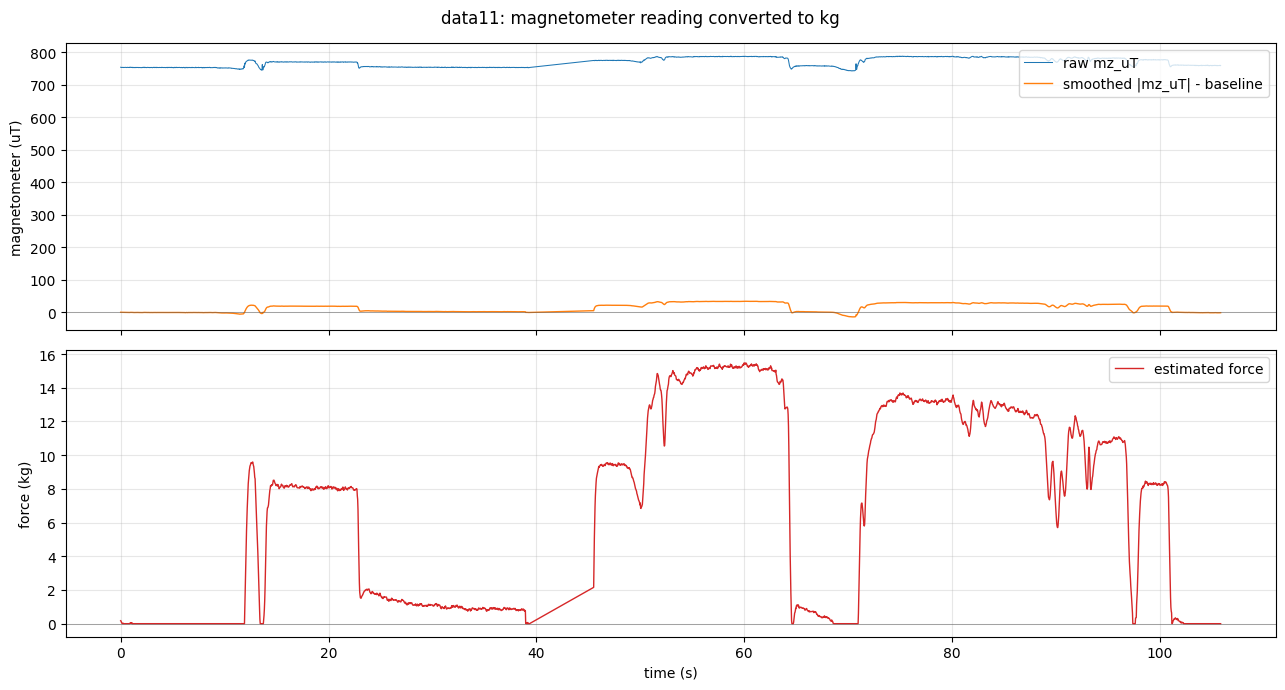

In [5]:
# RUN THIS CELL TO PLOT DATA11 MAGNETOMETER AND FORCE IN KG
plot_magnetometer_force_dataset("data11")

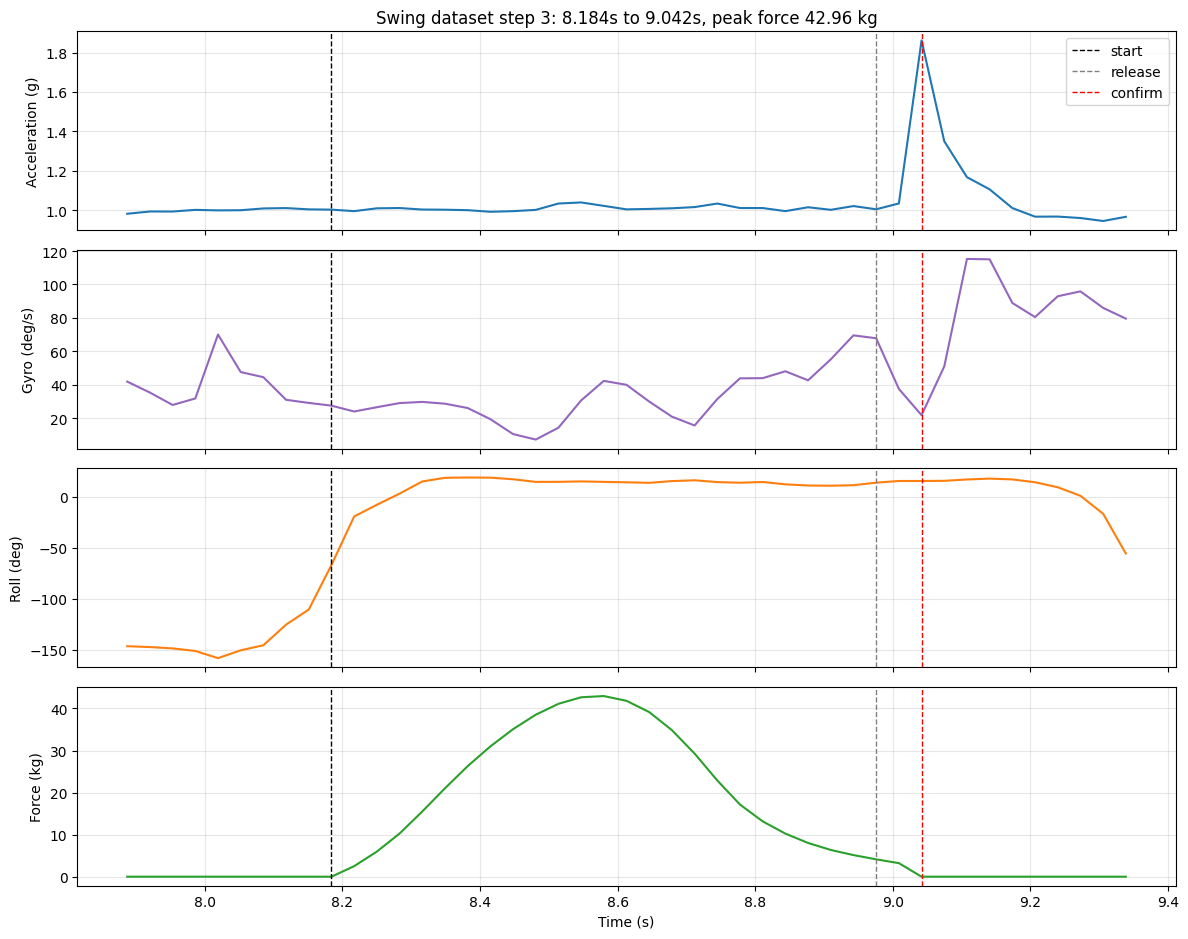

In [6]:
# Plot one accepted step from the swing dataset: acceleration, gyro, roll, and force.
detected_df, events_df, csv_path, startup_b0 = analyze_dataset("swing")

event_idx = 3
event = events_df.loc[event_idx]

pad_s = 0.30
start_s = event["start_s"]
release_s = event["release_s"]
confirm_s = event["confirm_s"]
window = detected_df[
    (detected_df["time_s"] >= start_s - pad_s)
    & (detected_df["time_s"] <= confirm_s + pad_s)
].copy()

fig, axes = plt.subplots(4, 1, figsize=(12, 9.5), sharex=True)

axes[0].plot(window["time_s"], window["accel_mag_g"], color="tab:blue")
axes[0].set_ylabel("Acceleration (g)")

axes[1].plot(window["time_s"], window["gyro_mag_dps"], color="tab:purple")
axes[1].set_ylabel("Gyro (deg/s)")

axes[2].plot(window["time_s"], window["roll_deg"], color="tab:orange")
axes[2].set_ylabel("Roll (deg)")

axes[3].plot(window["time_s"], window["force_kg"], color="tab:green")
axes[3].set_ylabel("Force (kg)")
axes[3].set_xlabel("Time (s)")

for ax in axes:
    ax.axvline(start_s, color="black", linestyle="--", linewidth=1, label="start")
    ax.axvline(release_s, color="gray", linestyle="--", linewidth=1, label="release")
    ax.axvline(confirm_s, color="red", linestyle="--", linewidth=1, label="confirm")
    ax.grid(True, alpha=0.3)

axes[0].set_title(
    f"Swing dataset step {event_idx}: "
    f"{start_s:.3f}s to {confirm_s:.3f}s, "
    f"peak force {event['peak_force_kg']:.2f} kg"
)

axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()